# **Import**

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import shap

from tqdm import tqdm

# **All Tests in A**

In [3]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [4]:
train_a = pd.read_csv('./train_a.csv')
train_a.head()

,Test_id,Test_x,Label,Test_y,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,...,A5-3,A6-1,A7-1,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5
0,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,A,0,A,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,50a,201906,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,15,0,1,10,12,6,10,14
1,0xDA572847455702C04D71C54677413CB8E31944B99289...,A,0,A,0xDA572847455702C04D71C54677413CB8E31944B99289...,60b,202206,"2,2,1,1,1,2,2,2,2,1,2,1,1,1,2,2,1,1","2,2,1,3,2,3,1,2,1,3,3,1,3,2,1,3,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",10,10,1,2,2,15,6,0,5
2,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,A,0,A,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,50a,201807,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,17,10,0,0,0,0,0,0
3,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,A,0,A,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,50a,202212,"1,1,2,2,1,1,2,2,2,2,1,2,1,1,2,1,2,1","3,3,2,2,3,2,1,1,3,3,1,2,1,2,1,1,3,2","0,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,14,7,1,5,1,0,20,9
4,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,A,0,A,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,40b,202001,"1,1,2,1,1,2,2,1,2,1,2,2,1,2,1,1,2,2","1,3,2,3,3,1,2,1,3,2,3,1,2,1,1,2,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,10,9,0,1,6,0,6,2


In [5]:
train_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 39 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     647241 non-null  object
 1   Test_x      647241 non-null  object
 2   Label       647241 non-null  int64 
 3   Test_y      647241 non-null  object
 4   PrimaryKey  647241 non-null  object
 5   Age         647241 non-null  object
 6   TestDate    647241 non-null  int64 
 7   A1-1        647241 non-null  object
 8   A1-2        647241 non-null  object
 9   A1-3        647241 non-null  object
 10  A1-4        647241 non-null  object
 11  A2-1        647240 non-null  object
 12  A2-2        647240 non-null  object
 13  A2-3        647240 non-null  object
 14  A2-4        647240 non-null  object
 15  A3-1        647240 non-null  object
 16  A3-2        647240 non-null  object
 17  A3-3        647240 non-null  object
 18  A3-4        647240 non-null  object
 19  A3-5        647240 non-

In [6]:
train_a = train_a.dropna()

## **Features**

In [7]:
list_cols = ['A1-3','A1-4','A2-3','A2-4','A3-5','A3-6','A3-7',
             'A4-3','A4-4','A4-5','A5-2','A5-3']

for col in list_cols:
    train_a[col + '_list'] = train_a[col].apply(lambda x: list(map(int, x.split(','))) if isinstance(x, str) else x)

In [8]:
train_a['A1-3_ratio'] = train_a['A1-3_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A1-4_mean'] = train_a['A1-4_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A1-4_std']  = train_a['A1-4_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [9]:
train_a['A2-3_ratio'] = train_a['A2-3_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A2-4_mean'] = train_a['A2-4_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A2-4_std']  = train_a['A2-4_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [10]:
train_a['A3-5_ratio'] = train_a['A3-5_list'].apply(lambda x: (x.count(1)+x.count(3))/len(x) if isinstance(x, list) else np.nan)
train_a['A3-6_ratio'] = train_a['A3-6_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A3-7_mean'] = train_a['A3-7_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A3-7_std']  = train_a['A3-7_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [11]:
train_a['A4-3_ratio'] = train_a['A4-3_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_a['A4-4_ratio'] = train_a['A4-4_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A4-5_mean'] = train_a['A4-5_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
train_a['A4-5_std']  = train_a['A4-5_list'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)

In [12]:
train_a['A5-2_ratio'] = train_a['A5-2_list'].apply(lambda x: x.count(1)/len(x) if isinstance(x, list) else np.nan)
train_a['A5-3_ratio'] = train_a['A5-3_list'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)

In [13]:
numeric_cols = ['A6-1','A7-1','A8-1','A8-2','A9-1','A9-2','A9-3','A9-4','A9-5']

train_a['A8_sum'] = train_a[['A8-1','A8-2']].sum(axis=1)
train_a['A9_sum'] = train_a[['A9-1','A9-2','A9-3','A9-4','A9-5']].sum(axis=1)
train_a['A8_mean'] = train_a[['A8-1','A8-2']].mean(axis=1)
train_a['A9_mean'] = train_a[['A9-1','A9-2','A9-3','A9-4','A9-5']].mean(axis=1)

In [14]:
train_a['Age_num'] = train_a['Age'].str.extract(r'(\d+)').astype(int)

In [15]:
feature_cols = [
    'A1-3_ratio','A1-4_mean','A1-4_std',
    'A2-3_ratio','A2-4_mean','A2-4_std',
    'A3-5_ratio','A3-6_ratio','A3-7_mean','A3-7_std',
    'A4-3_ratio','A4-4_ratio','A4-5_mean','A4-5_std',
    'A5-2_ratio','A5-3_ratio',
    'A6-1','A7-1','A8-1','A8-2',
    'A9-1','A9-2','A9-3','A9-4','A9-5',
    'A8_sum','A9_sum','A8_mean','A9_mean',
    'Age_num','Label'
]

train_a = train_a[feature_cols]

In [16]:
train_a.head()

,A1-3_ratio,A1-4_mean,A1-4_std,A2-3_ratio,A2-4_mean,A2-4_std,A3-5_ratio,A3-6_ratio,A3-7_mean,A3-7_std,...,A9-2,A9-3,A9-4,A9-5,A8_sum,A9_sum,A8_mean,A9_mean,Age_num,Label
0,0.000000,-42.111111,22.290728,0.0,-80.277778,23.203940,1.00000,0.0,819.71875,214.698078,...,12,6,10,14,1,52,0.5,10.4,50,0
1,0.000000,-54.222222,38.676084,0.0,-49.000000,59.167371,1.00000,0.0,1066.65625,252.897535,...,15,6,0,5,3,28,1.5,5.6,60,0
2,0.000000,-42.111111,22.290728,0.0,-80.277778,23.203940,1.00000,0.0,819.71875,214.698078,...,0,0,0,0,10,0,5.0,0.0,50,0
3,0.277778,178.333333,294.873984,0.0,-27.500000,42.353342,0.96875,0.0,874.12500,389.961276,...,1,0,20,9,8,35,4.0,7.0,50,0
4,0.000000,-9.666667,75.914426,0.0,-1.222222,31.117261,1.00000,0.0,820.59375,306.168444,...,6,0,6,2,9,15,4.5,3.0,40,0


In [17]:
train_a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647237 entries, 0 to 647240
Data columns (total 31 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   A1-3_ratio  647237 non-null  float64
 1   A1-4_mean   647237 non-null  float64
 2   A1-4_std    647237 non-null  float64
 3   A2-3_ratio  647237 non-null  float64
 4   A2-4_mean   647237 non-null  float64
 5   A2-4_std    647237 non-null  float64
 6   A3-5_ratio  647237 non-null  float64
 7   A3-6_ratio  647237 non-null  float64
 8   A3-7_mean   647237 non-null  float64
 9   A3-7_std    647237 non-null  float64
 10  A4-3_ratio  647237 non-null  float64
 11  A4-4_ratio  647237 non-null  float64
 12  A4-5_mean   647237 non-null  float64
 13  A4-5_std    647237 non-null  float64
 14  A5-2_ratio  647237 non-null  float64
 15  A5-3_ratio  647237 non-null  float64
 16  A6-1        647237 non-null  int64  
 17  A7-1        647237 non-null  int64  
 18  A8-1        647237 non-null  int64  
 19  A8-2   

## **Correlation**

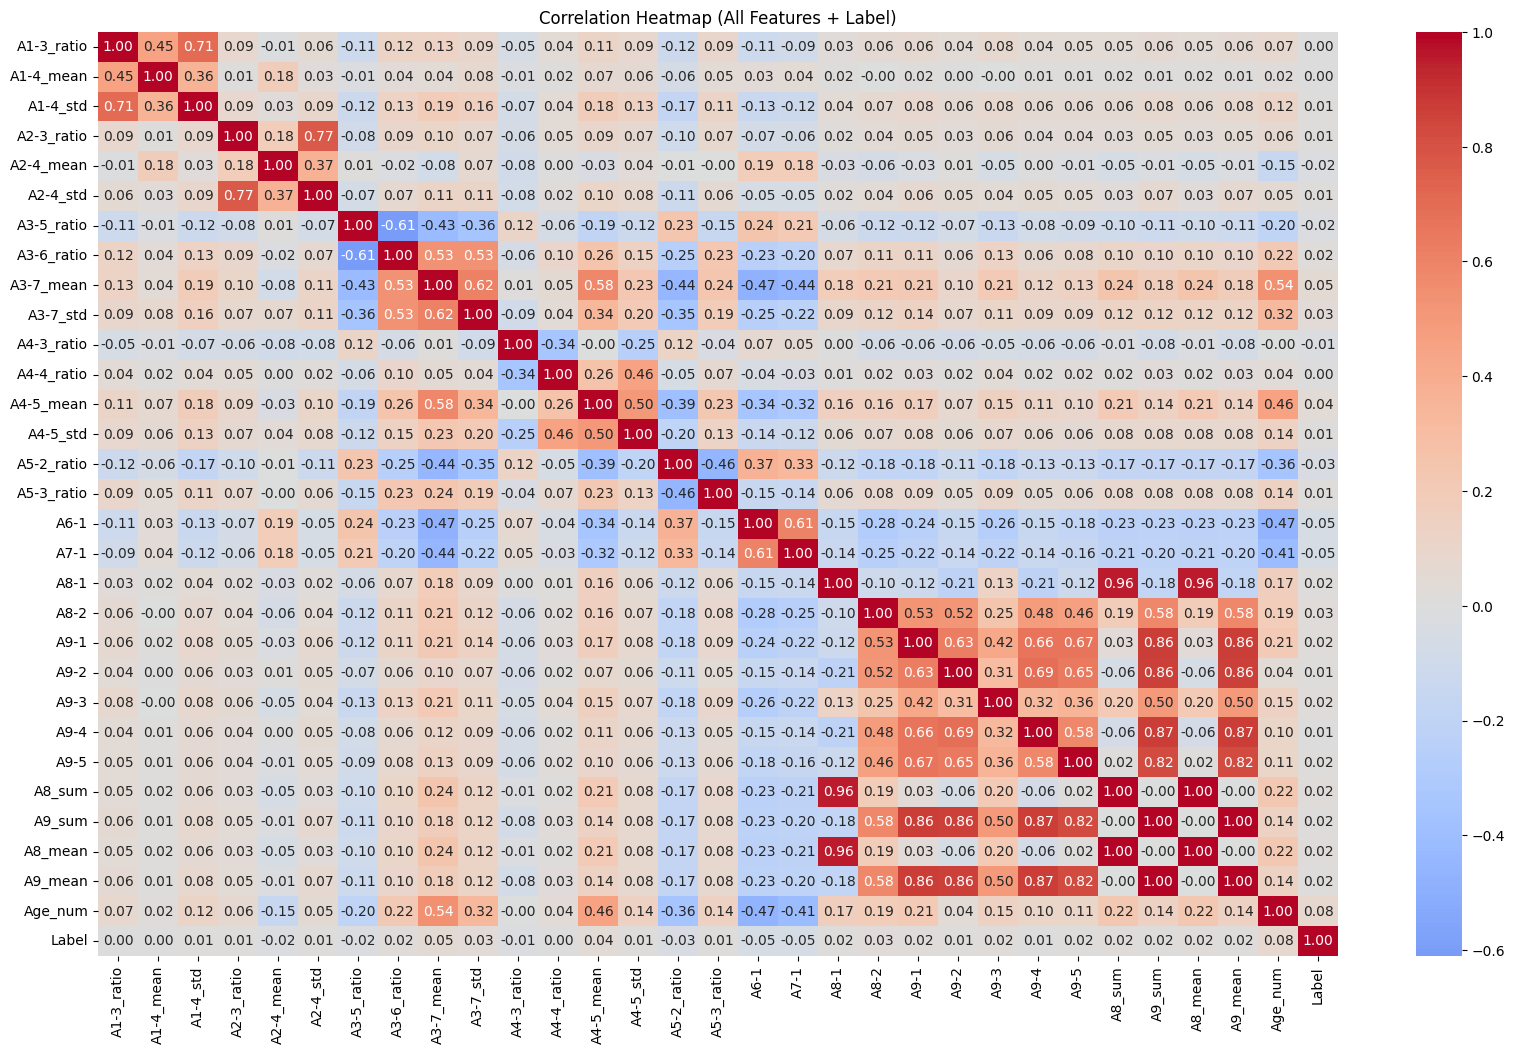

In [18]:
corr_matrix = train_a.corr()

plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (All Features + Label)")
plt.show()

### Under Sampling

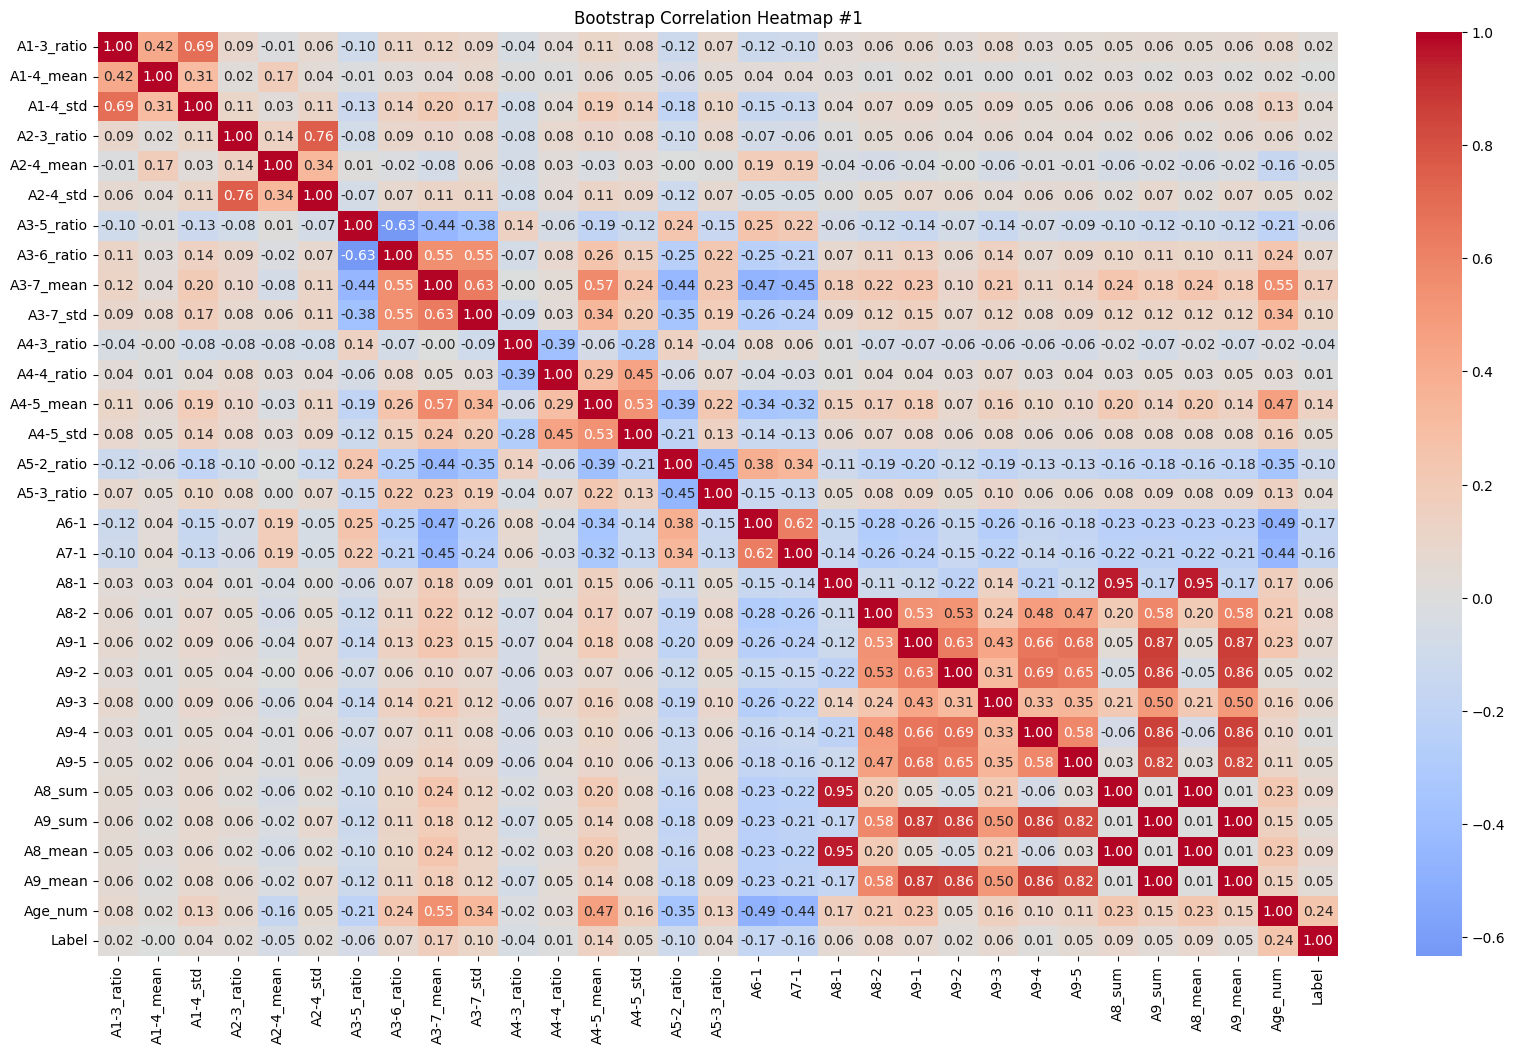

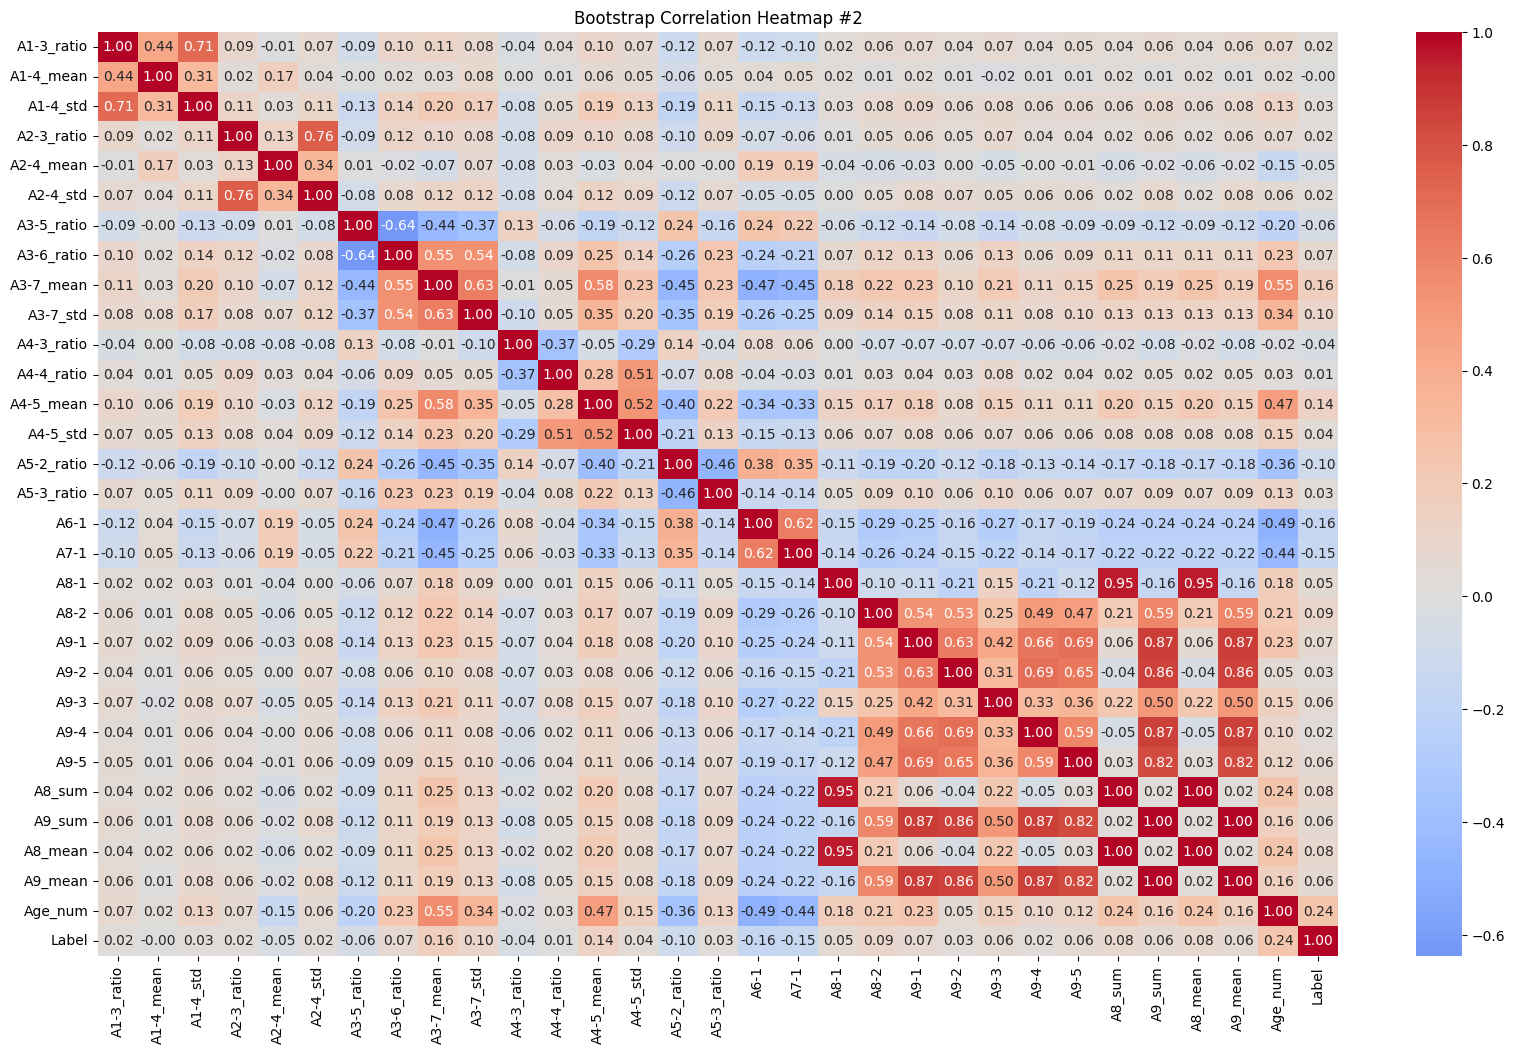

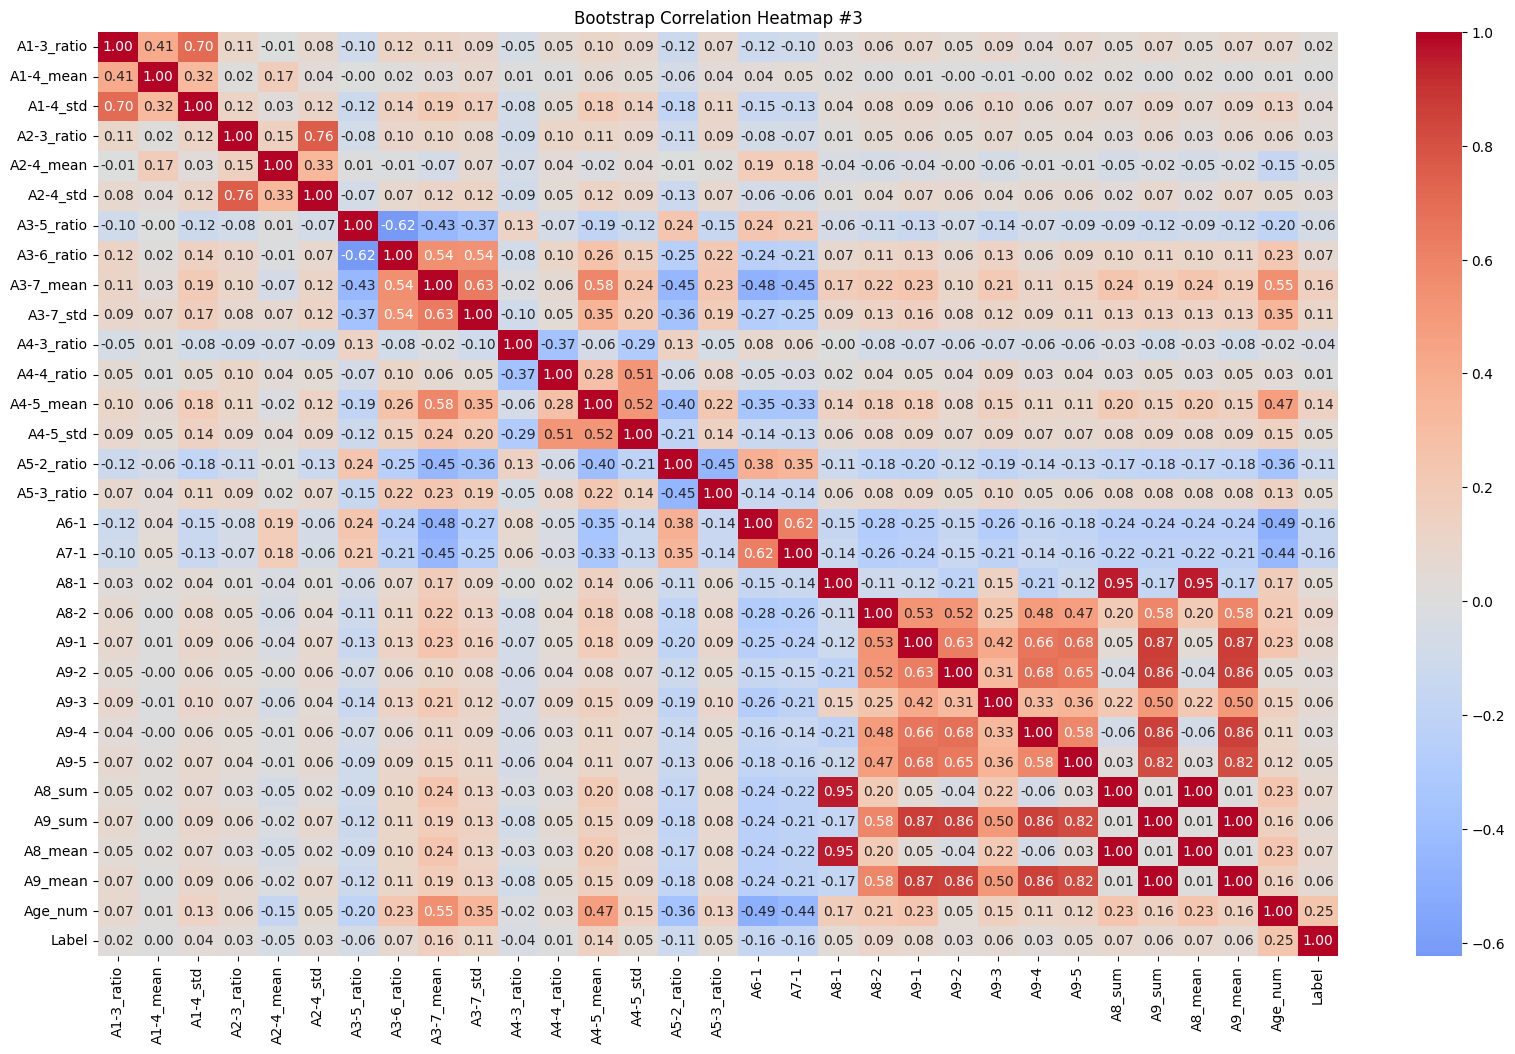

In [19]:
df_label1 = train_a[train_a['Label'] == 1]
df_label0 = train_a[train_a['Label'] == 0]

n_label1 = len(df_label1)
n_label0 = len(df_label0)

# 0 데이터를 label1 크기에 맞춰 무작위로 샘플링
sample_size = n_label1

np.random.seed(42)  # 재현성

# 테스트로 3개의 히트맵
for i in range(3):
    # Label 0에서 서브샘플링
    df0_sample = df_label0.sample(n=sample_size, replace=False)
    # Label 1과 합치기
    df_bootstrap = pd.concat([df_label1, df0_sample], axis=0).reset_index(drop=True)
    # 상관계수 계산
    corr_matrix = df_bootstrap.corr()

    # 히트맵
    plt.figure(figsize=(20,12))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title(f"Bootstrap Correlation Heatmap #{i+1}")
    plt.show()

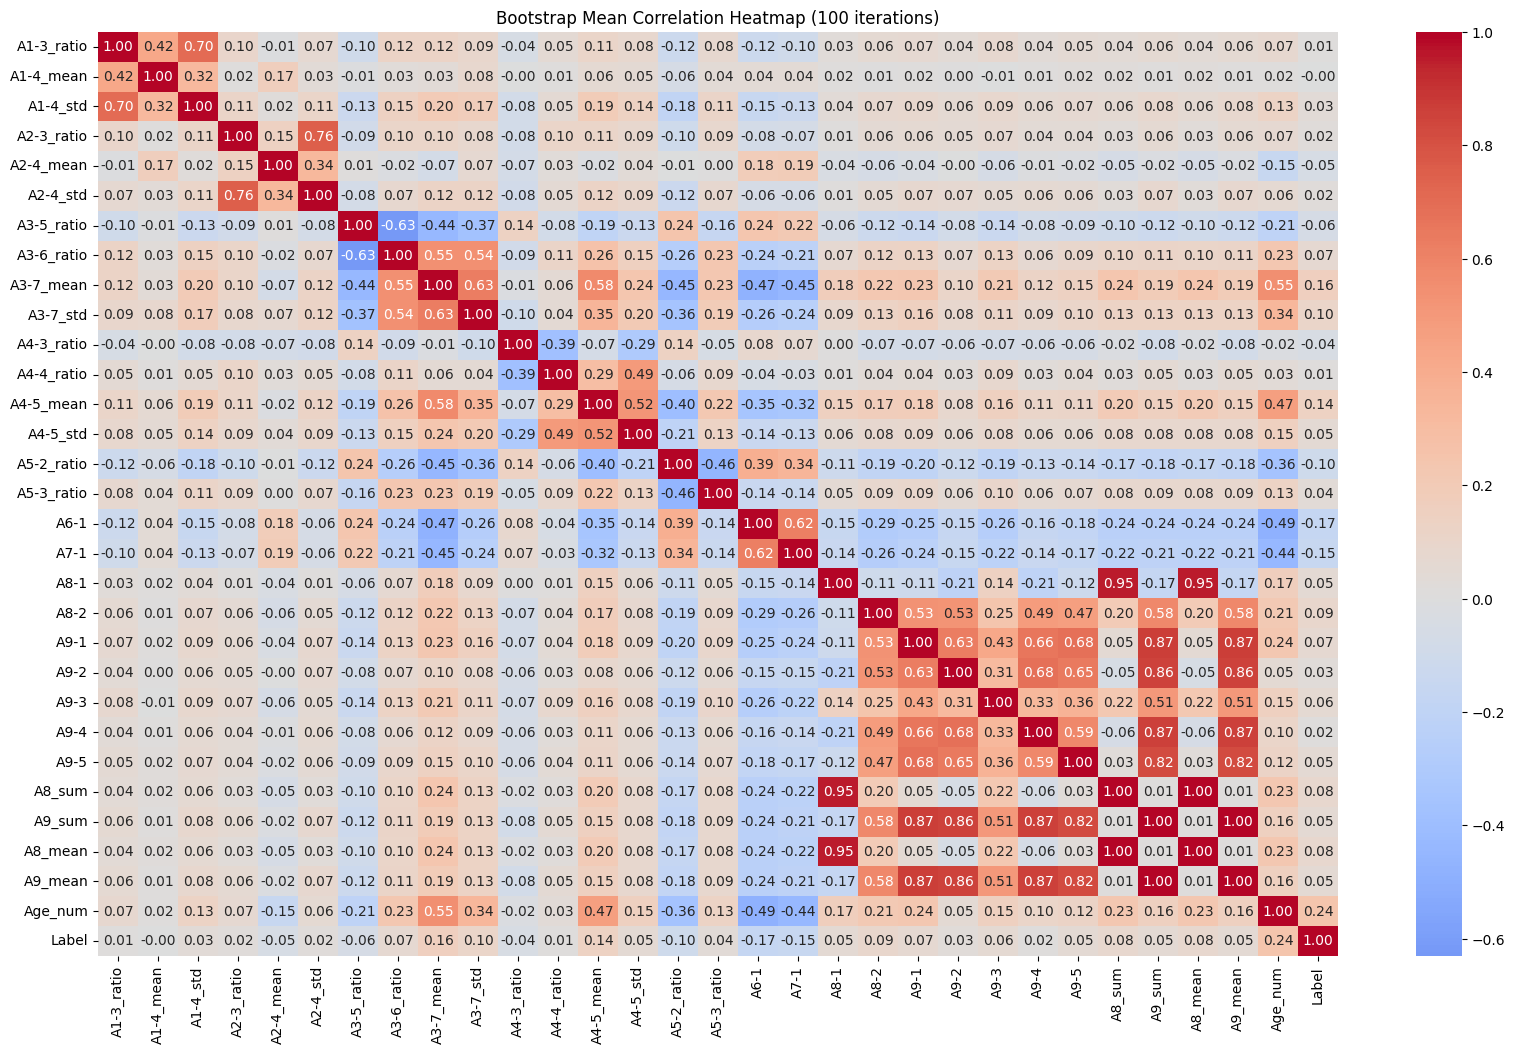

In [20]:
cols = ['A1-3_ratio', 'A1-4_mean', 'A1-4_std', 'A2-3_ratio', 'A2-4_mean',
        'A2-4_std', 'A3-5_ratio', 'A3-6_ratio', 'A3-7_mean', 'A3-7_std',
        'A4-3_ratio', 'A4-4_ratio', 'A4-5_mean', 'A4-5_std', 'A5-2_ratio',
        'A5-3_ratio', 'A6-1', 'A7-1', 'A8-1', 'A8-2', 'A9-1', 'A9-2', 'A9-3',
        'A9-4', 'A9-5', 'A8_sum', 'A9_sum', 'A8_mean', 'A9_mean', 'Age_num',
        'Label']

# Label 1과 Label 0 나누기
df_label1 = train_a[train_a['Label'] == 1]
df_label0 = train_a[train_a['Label'] == 0]

n_label1 = len(df_label1)
sample_size = n_label1

np.random.seed(42)  # 재현성

# 반복 횟수
n_bootstrap = 100

# 히트맵 평균 저장용
corr_accum = np.zeros((len(cols), len(cols)))

for i in range(n_bootstrap):
    # Label 0에서 서브샘플링
    df0_sample = df_label0.sample(n=sample_size, replace=False)
    # Label 1과 합치기
    df_bootstrap = pd.concat([df_label1, df0_sample], axis=0).reset_index(drop=True)
    # 상관계수 계산
    corr_matrix = df_bootstrap.corr()
    corr_accum += corr_matrix.values

# 평균 상관계수 계산
corr_mean = corr_accum / n_bootstrap
corr_mean_df = pd.DataFrame(corr_mean, index=cols, columns=cols)

# 평균 히트맵
plt.figure(figsize=(20, 12))
sns.heatmap(corr_mean_df, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title(f"Bootstrap Mean Correlation Heatmap ({n_bootstrap} iterations)")
plt.show()

Label과 상관계수 상위 변수: ['Label', 'Age_num', 'A6-1', 'A3-7_mean', 'A7-1', 'A4-5_mean', 'A5-2_ratio', 'A3-7_std', 'A8-2', 'A8_sum']


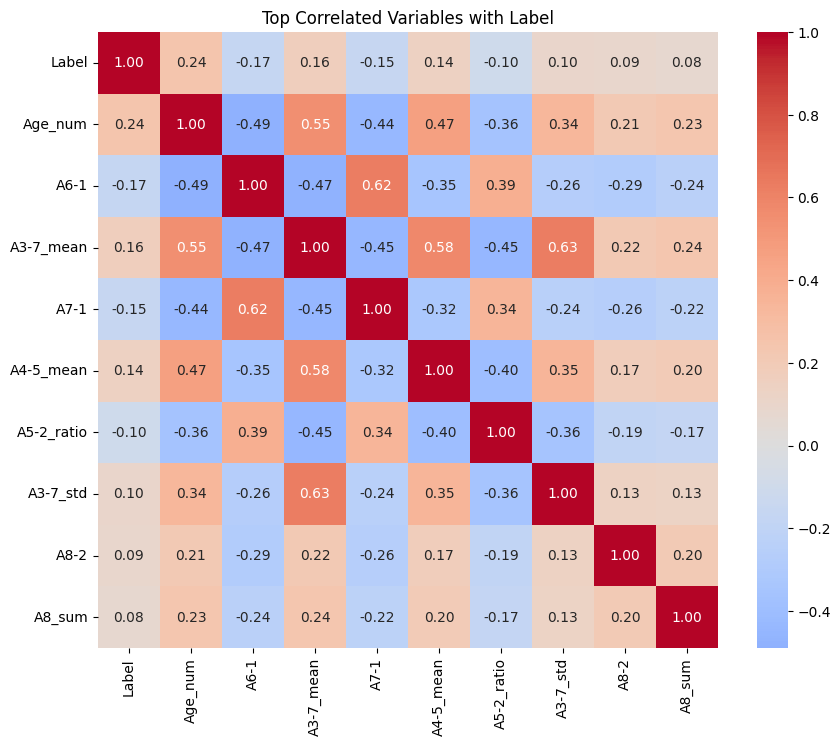

In [21]:
label_corr = corr_mean_df['Label']

# 절댓값 기준 내림차순 정렬
label_corr_sorted = label_corr.abs().sort_values(ascending=False)

# Label과 상관계수 상위 10개 변수 (Label 포함)
top_vars = label_corr_sorted.head(10).index.tolist()

print("Label과 상관계수 상위 변수:", top_vars)

# 상위 변수들만 히트맵 그리기
plt.figure(figsize=(10,8))
sns.heatmap(corr_mean_df.loc[top_vars, top_vars], annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Top Correlated Variables with Label")
plt.show()

### Over Sampling

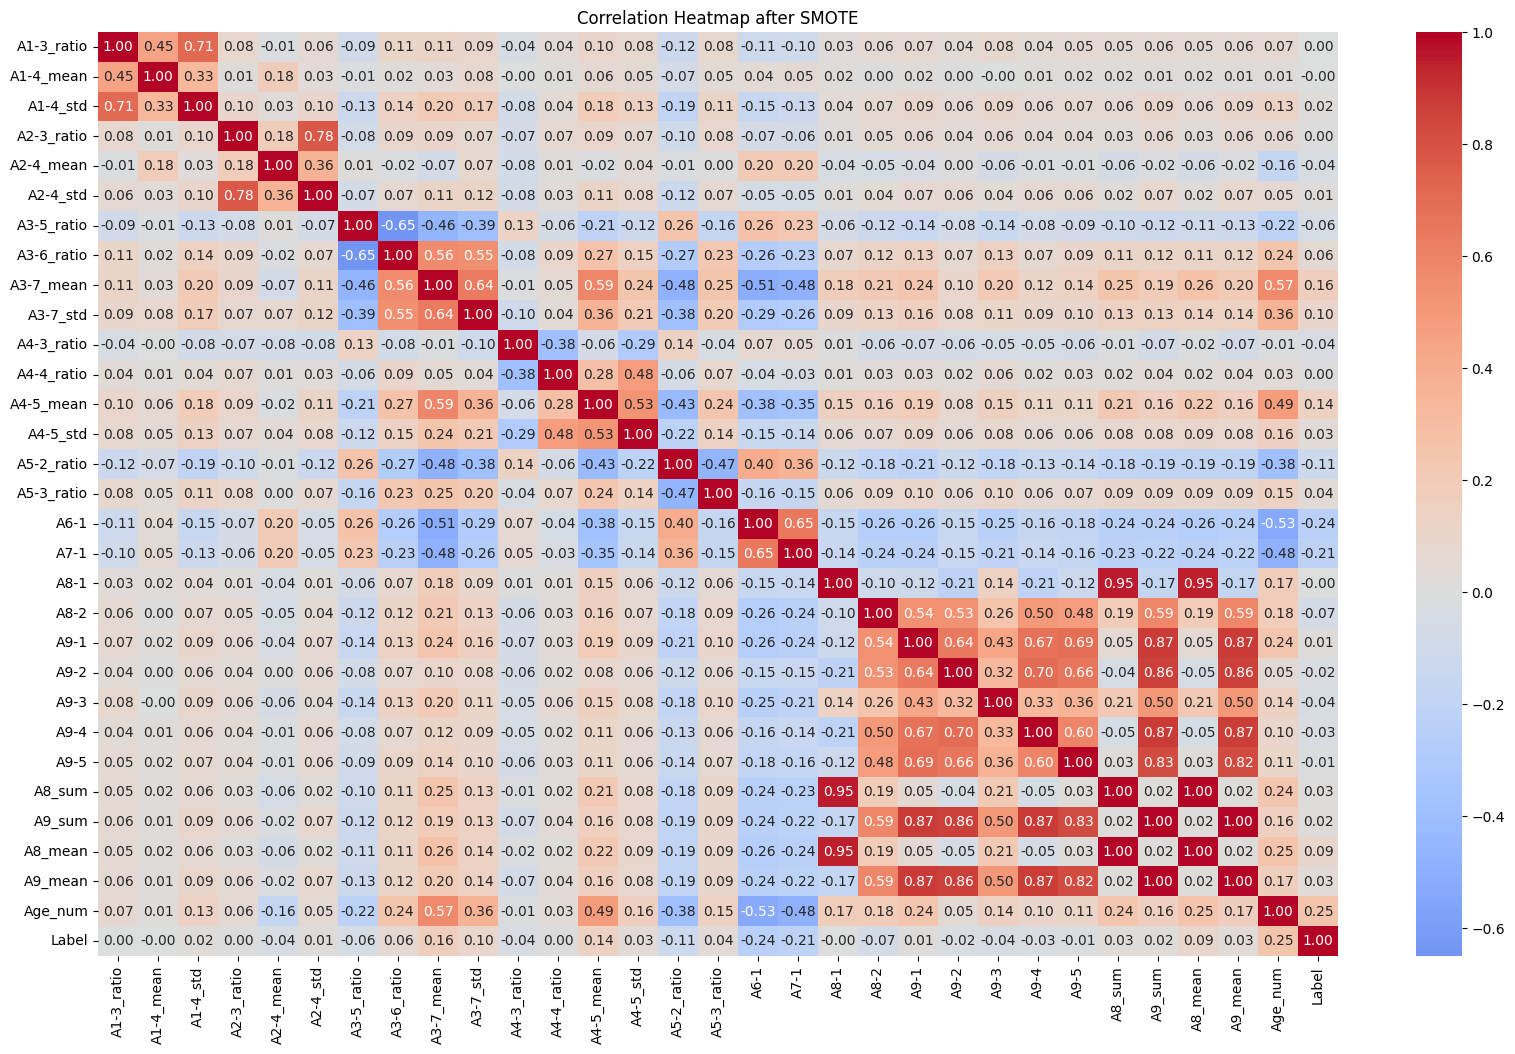

In [22]:
cols = ['A1-3_ratio', 'A1-4_mean', 'A1-4_std', 'A2-3_ratio', 'A2-4_mean',
        'A2-4_std', 'A3-5_ratio', 'A3-6_ratio', 'A3-7_mean', 'A3-7_std',
        'A4-3_ratio', 'A4-4_ratio', 'A4-5_mean', 'A4-5_std', 'A5-2_ratio',
        'A5-3_ratio', 'A6-1', 'A7-1', 'A8-1', 'A8-2', 'A9-1', 'A9-2', 'A9-3',
        'A9-4', 'A9-5', 'A8_sum', 'A9_sum', 'A8_mean', 'A9_mean', 'Age_num',
        'Label']

tmp = train_a.copy()

x = tmp.drop('Label', axis=1)
y = tmp['Label']

smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

df_res = x_res.copy()
df_res['Label'] = y_res

corr_res = df_res.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(corr_res, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap after SMOTE")
plt.show()

Label과 상관계수 상위 변수: ['Label', 'Age_num', 'A6-1', 'A7-1', 'A3-7_mean', 'A4-5_mean', 'A5-2_ratio', 'A3-7_std', 'A8_mean', 'A8-2']


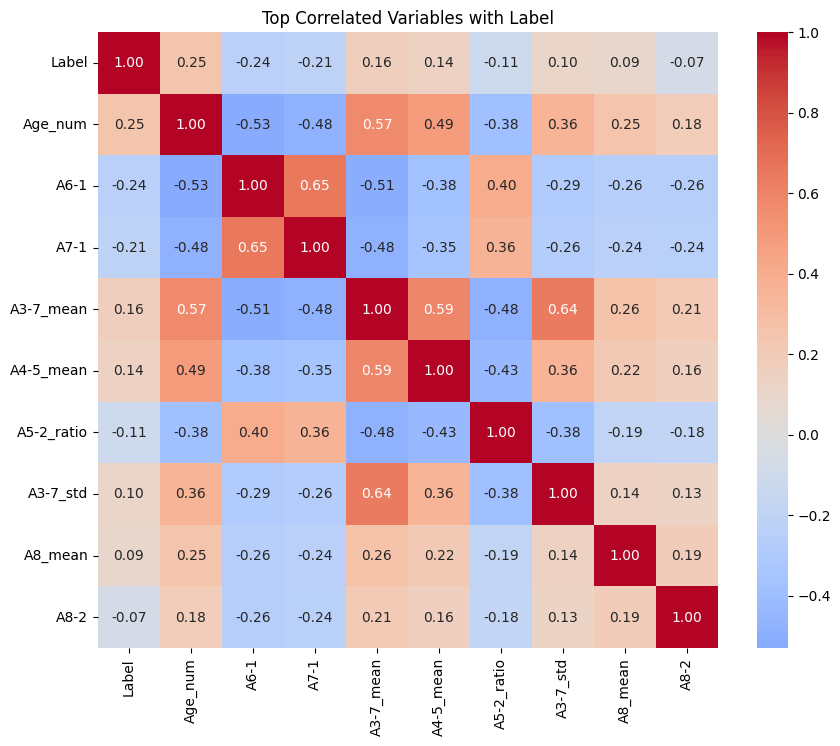

In [23]:
label_corr = corr_res['Label']

# 절댓값 기준 내림차순 정렬
label_corr_sorted = label_corr.abs().sort_values(ascending=False)

# Label과 상관계수 상위 10개 변수 (Label 포함)
top_vars = label_corr_sorted.head(10).index.tolist()

print("Label과 상관계수 상위 변수:", top_vars)

# 상위 변수들만 히트맵 그리기
plt.figure(figsize=(10,8))
sns.heatmap(corr_res.loc[top_vars, top_vars], annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Top Correlated Variables with Label")
plt.show()

### LightGBM

In [24]:
cols = ['A1-3_ratio', 'A1-4_mean', 'A1-4_std', 'A2-3_ratio', 'A2-4_mean',
        'A2-4_std', 'A3-5_ratio', 'A3-6_ratio', 'A3-7_mean', 'A3-7_std',
        'A4-3_ratio', 'A4-4_ratio', 'A4-5_mean', 'A4-5_std', 'A5-2_ratio',
        'A5-3_ratio', 'A6-1', 'A7-1', 'A8-1', 'A8-2', 'A9-1', 'A9-2', 'A9-3',
        'A9-4', 'A9-5', 'A8_sum', 'A9_sum', 'A8_mean', 'A9_mean', 'Age_num']

x = train_a[cols]
y = train_a['Label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',  # 불균형 고려
    random_state=42
)

model.fit(x_train, y_train)

importances = pd.DataFrame({
    'feature': cols,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances.head(20))  # 상위 20개 확인

[LightGBM] [Info] Number of positive: 11754, number of negative: 506035
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2963
[LightGBM] [Info] Number of data points in the train set: 517789, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
       feature  importance
9     A3-7_std        1060
4    A2-4_mean        1013
5     A2-4_std         988
12   A4-5_mean         986
8    A3-7_mean         976
13    A4-5_std         975
2     A1-4_std         962
1    A1-4_mean         960
23        A9-4         603
17        A7-1         565
21        A9-2         554
26      A9_sum         545
24        A9-5         538
20        A9-1         505
14  A5-2_ratio         502
16      

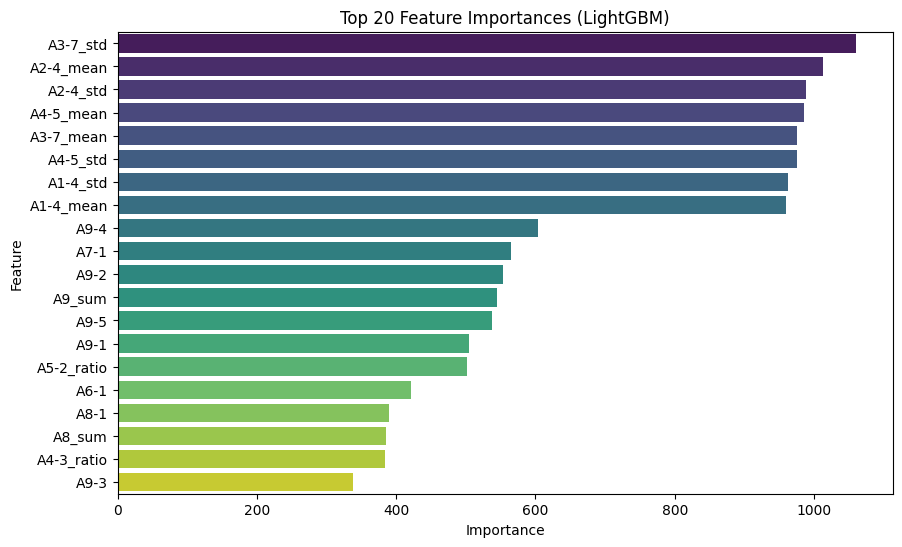

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### SHAP

Computing SHAP values: 100%|██████████| 518/518 [10:21<00:00,  1.20s/it]


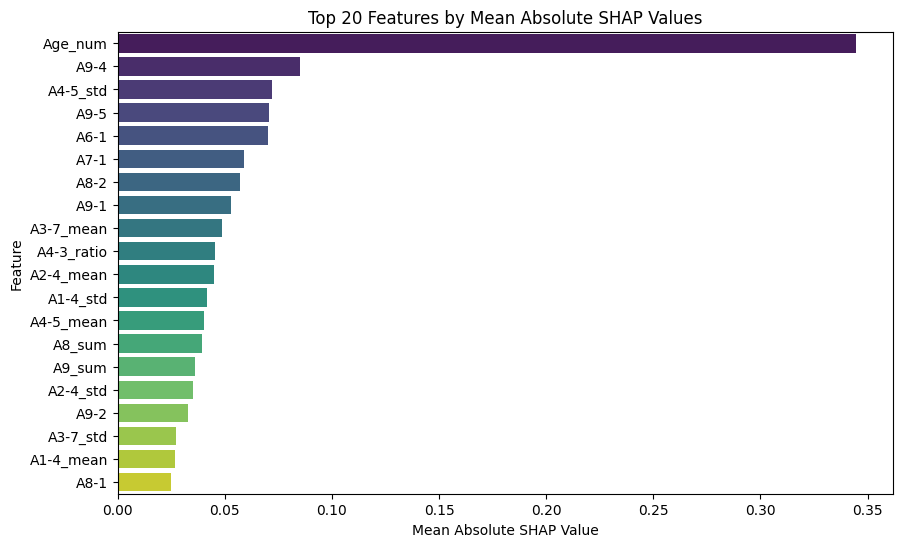

In [26]:
explainer = shap.TreeExplainer(model)

batch_size = 1000
n_samples = len(x_train)
shap_values_list = []

for i in tqdm(range(0, n_samples, batch_size), desc="Computing SHAP values"):
    x_batch = x_train.iloc[i:i+batch_size]
    shap_values_batch = explainer.shap_values(x_batch)[1]  # 이진분류이므로 [1]
    shap_values_list.append(shap_values_batch)

# 전체 shap_values 합치기
shap_values_class1 = np.vstack(shap_values_list)

# 평균 절댓값 계산
shap_abs_mean = pd.DataFrame({
    'feature': x_train.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

# 시각화
plt.figure(figsize=(10,6))
sns.barplot(data=shap_abs_mean.head(20), x='mean_abs_shap', y='feature', palette='viridis')
plt.title('Top 20 Features by Mean Absolute SHAP Values')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.show()
